# CH 5 - 5 : RATIONALE OF THE HYPOTHESIS TEST

## Objectif pédagogique

Ce notebook transforme le concept de **raisonnement du test d’hypothèse** en outil concret pour le trading et le backtest.

L’idée centrale : on ne part pas du principe qu’une stratégie est bonne. On part de l’hypothèse inverse :

- **$H_0$ : la stratégie n’a pas de talent réel** ; son rendement moyen attendu est égal ou inférieur à zéro.
- **$H_A$ : la stratégie a un talent réel** ; son rendement moyen attendu est supérieur à zéro.

Le test statistique sert à répondre à une question simple :

> Le profit observé dans le backtest est-il suffisamment improbable si la stratégie n’avait aucun edge ?

Si oui, on rejette $H_0$. Sinon, on garde l’explication prudente : le profit peut venir du hasard.


## 1. L’intuition EBTA

Dans un backtest, un profit positif ne suffit pas. Même une règle inutile peut gagner temporairement par chance.

Le raisonnement scientifique inverse la charge de la preuve :

1. On suppose que la stratégie est nulle.
2. On simule ou modélise ce que le hasard pourrait produire.
3. On compare le rendement observé à cette distribution du hasard.
4. Si le rendement observé est dans une zone très rare, on rejette l’hypothèse de hasard.

En trading, cela évite de confondre une vraie inefficience exploitable avec une simple fluctuation favorable dans l’échantillon.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 2. Exemple simple : une stratégie observée à +8% annualisé

Imaginons une stratégie testée sur 252 jours. Elle affiche un rendement moyen quotidien positif qui correspond à environ **+8% annualisé**.

La question EBTA n’est pas : « Est-ce que +8% est bien ? »

La vraie question est : « Est-ce que +8% est rare si la stratégie n’a aucun edge réel ? »

Pour le tester, on crée une hypothèse nulle où le rendement moyen attendu est zéro.


In [2]:
# Paramètres du backtest
n_days = 252
observed_annual_return = 0.08
observed_daily_mean = observed_annual_return / 252

# Hypothèse nulle : rendement moyen réel = 0
null_mean = 0.0

# Volatilité quotidienne supposée de la stratégie
# Ici 1% par jour, ce qui est courant pour une stratégie active.
daily_vol = 0.01

# Erreur standard de la moyenne quotidienne
standard_error = daily_vol / np.sqrt(n_days)

# Statistique z : distance entre le rendement observé et H0
z_score = (observed_daily_mean - null_mean) / standard_error

z_score


np.float64(0.5039526306789697)

## 3. Visualiser le duel entre $H_0$ et le résultat observé

La distribution ci-dessous représente les rendements annualisés que le hasard pourrait produire si la stratégie n’avait aucun edge.

Le trait vertical représente le rendement observé dans le backtest. Plus ce trait est loin dans la queue droite, plus il devient difficile de dire : « ce n’est que de la chance ».


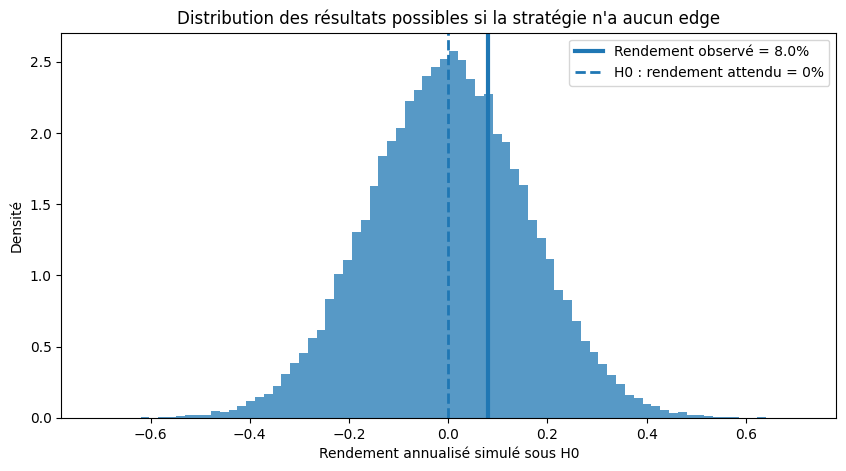

Rendement observé : 8.00%
z-score : 0.50
p-value unilatérale : 0.3076


In [3]:
# Simulation de rendements moyens sous H0
n_simulations = 50_000

null_daily_means = np.random.normal(
    loc=0,
    scale=standard_error,
    size=n_simulations
)

null_annual_returns = null_daily_means * 252

# p-value unilatérale : probabilité de faire aussi bien ou mieux sous H0
p_value = np.mean(null_annual_returns >= observed_annual_return)

plt.figure(figsize=(10, 5))
plt.hist(null_annual_returns, bins=80, density=True, alpha=0.75)
plt.axvline(observed_annual_return, linewidth=3, label=f"Rendement observé = {observed_annual_return:.1%}")
plt.axvline(0, linestyle="--", linewidth=2, label="H0 : rendement attendu = 0%")
plt.title("Distribution des résultats possibles si la stratégie n'a aucun edge")
plt.xlabel("Rendement annualisé simulé sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()

print(f"Rendement observé : {observed_annual_return:.2%}")
print(f"z-score : {z_score:.2f}")
print(f"p-value unilatérale : {p_value:.4f}")


## 4. Interprétation pratique

La p-value répond à cette question :

> Si la stratégie était réellement nulle, quelle serait la probabilité d’obtenir un résultat aussi bon ou meilleur ?

Règle de décision classique :

- Si **p-value < 0,05**, le résultat est rare sous $H_0$ : on peut rejeter $H_0$.
- Si **p-value ≥ 0,05**, le résultat n’est pas assez rare : on ne rejette pas $H_0$.

Attention : ne pas rejeter $H_0$ ne prouve pas que la stratégie est mauvaise. Cela signifie seulement que l’évidence est insuffisante.


In [4]:
alpha = 0.05

if p_value < alpha:
    decision = "Rejet de H0 : le résultat est statistiquement rare sous l'hypothèse de hasard."
else:
    decision = "Non-rejet de H0 : le résultat peut raisonnablement venir du hasard."

print(decision)


Non-rejet de H0 : le résultat peut raisonnablement venir du hasard.


## 5. Pourquoi la largeur de la distribution est cruciale

Un même rendement observé peut être impressionnant ou banal selon la variabilité de la stratégie.

Deux facteurs élargissent ou réduisent la distribution sous $H_0$ :

1. **La volatilité des rendements** : plus les rendements quotidiens sont dispersés, plus le hasard peut produire de gros résultats.
2. **Le nombre d’observations** : plus le backtest contient de jours, plus la moyenne observée devient fiable.

C’est pour cela qu’un +8% obtenu avec peu de trades ou beaucoup de volatilité n’a pas la même valeur qu’un +8% obtenu sur un grand échantillon stable.


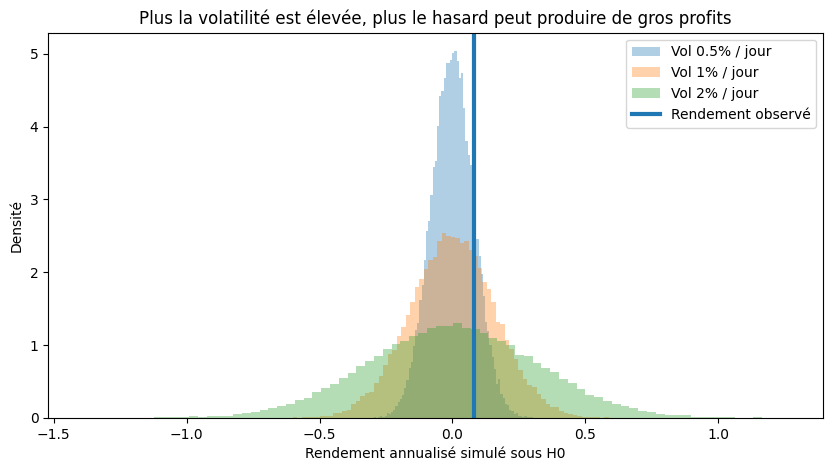

In [5]:
volatilities = [0.005, 0.01, 0.02]
labels = ["Vol 0.5% / jour", "Vol 1% / jour", "Vol 2% / jour"]

plt.figure(figsize=(10, 5))

for vol, label in zip(volatilities, labels):
    se = vol / np.sqrt(n_days)
    simulated = np.random.normal(0, se, n_simulations) * 252
    plt.hist(simulated, bins=80, density=True, alpha=0.35, label=label)

plt.axvline(observed_annual_return, linewidth=3, label="Rendement observé")
plt.title("Plus la volatilité est élevée, plus le hasard peut produire de gros profits")
plt.xlabel("Rendement annualisé simulé sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 6. Exemple orienté trading : tester une série de rendements de stratégie

Dans la pratique, tu disposes souvent d’une série de rendements journaliers provenant d’un backtest.

On peut estimer le rendement moyen annualisé, la volatilité annualisée, le z-score et la p-value unilatérale.

Cet exemple reste volontairement simple. Il sert à comprendre la logique avant d’utiliser des méthodes plus robustes comme le bootstrap ou White’s Reality Check.


In [6]:
def hypothesis_test_strategy_returns(daily_returns, periods_per_year=252, alpha=0.05):
    # Test unilatéral simplifié :
    # H0 : rendement moyen <= 0
    # HA : rendement moyen > 0
    # Hypothèse technique simplificatrice : moyenne approximativement normale.
    daily_returns = np.asarray(daily_returns)
    n = len(daily_returns)
    mean_daily = daily_returns.mean()
    vol_daily = daily_returns.std(ddof=1)
    se = vol_daily / np.sqrt(n)
    z = mean_daily / se
    
    # Approximation de la p-value par simulation sous H0
    null_means = np.random.normal(0, se, 100_000)
    p = np.mean(null_means >= mean_daily)
    
    result = {
        "Nombre d'observations": n,
        "Rendement annualisé observé": mean_daily * periods_per_year,
        "Volatilité annualisée": vol_daily * np.sqrt(periods_per_year),
        "z-score": z,
        "p-value unilatérale": p,
        "Décision": "Rejeter H0" if p < alpha else "Ne pas rejeter H0"
    }
    return pd.Series(result)

# Exemple : stratégie avec petit edge simulé
strategy_returns = np.random.normal(loc=0.00035, scale=0.01, size=252)

hypothesis_test_strategy_returns(strategy_returns)


Nombre d'observations                        252
Rendement annualisé observé             0.038726
Volatilité annualisée                   0.159813
z-score                                 0.242321
p-value unilatérale                      0.40368
Décision                       Ne pas rejeter H0
dtype: object

## 7. Comparer une stratégie fragile et une stratégie plus convaincante

Deux stratégies peuvent avoir un rendement positif, mais pas la même force statistique.

La stratégie qui mérite davantage ton attention n’est pas seulement celle qui gagne le plus. C’est celle dont le résultat est le moins compatible avec l’hypothèse de hasard.


In [12]:
np.random.seed(7)

fragile_strategy = np.random.normal(loc=0.00025, scale=0.02, size=120)
stronger_strategy = np.random.normal(loc=0.00035, scale=0.008, size=500)

comparison = pd.DataFrame({
    "Stratégie fragile": hypothesis_test_strategy_returns(fragile_strategy),
    "Stratégie plus convaincante": hypothesis_test_strategy_returns(stronger_strategy)
})

comparison


,Stratégie fragile,Stratégie plus convaincante
Nombre d'observations,120,500
Rendement annualisé observé,0.218423,-0.052243
Volatilité annualisée,0.318037,0.123767
z-score,0.473928,-0.594584
p-value unilatérale,0.31657,0.72462
Décision,Ne pas rejeter H0,Ne pas rejeter H0


## 8. Lecture EBTA du résultat

Une bonne décision statistique ne dit pas :

> Cette stratégie a gagné, donc elle est bonne.

Elle dit plutôt :

> En supposant que cette stratégie soit nulle, son résultat serait-il suffisamment improbable ?

C’est ce renversement mental qui protège le trader contre l’excès de confiance, le data mining et les illusions de backtest.


## 9. À retenir absolument

- Le test d’hypothèse commence par le scepticisme.
- $H_0$ représente l’explication par défaut : pas de talent, seulement du hasard.
- $H_A$ n’est acceptée qu’indirectement, quand $H_0$ devient difficile à défendre.
- Une p-value faible ne prouve pas une stratégie parfaite, elle indique seulement que le résultat est rare sous $H_0$.
- Une p-value élevée ne prouve pas que la stratégie est nulle, elle indique que les preuves sont insuffisantes.
- En trading, le rôle du test est de protéger ton capital mental et financier contre les faux edges.


## 10. Extension pour ton process de trader

Avant de valider une règle, tu peux ajouter cette checklist :

1. La règle est-elle définie avant le test ?
2. Le nombre d’observations est-il suffisant ?
3. Le rendement est-il testé contre une hypothèse nulle réaliste ?
4. Les données ont-elles été dé-tendancées si nécessaire ?
5. La p-value est-elle inférieure au seuil fixé à l’avance ?
6. Le résultat survit-il à un test out-of-sample ou walk-forward ?
7. Le résultat survit-il après coûts, spread et slippage ?

Une règle ne devient intéressante que lorsqu’elle résiste à la tentative de falsification.
